In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("train.csv")

In [3]:
df.head(5)

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   date    913000 non-null  object
 1   store   913000 non-null  int64 
 2   item    913000 non-null  int64 
 3   sales   913000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 27.9+ MB


In [5]:
df.describe()

,store,item,sales
count,913000.000000,913000.000000,913000.000000
mean,5.500000,25.500000,52.250287
std,2.872283,14.430878,28.801144
min,1.000000,1.000000,0.000000
25%,3.000000,13.000000,30.000000
50%,5.500000,25.500000,47.000000
75%,8.000000,38.000000,70.000000
max,10.000000,50.000000,231.000000


In [6]:
df.isnull().sum()

date     0
store    0
item     0
sales    0
dtype: int64

In [7]:
df['date'] = pd.to_datetime(df['date'])

In [8]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['day_of_week'] = df['date'].dt.dayofweek

In [9]:
#now we will check our data again
df.head(5)

,date,store,item,sales,year,month,day,day_of_week
0,2013-01-01,1,1,13,2013,1,1,1
1,2013-01-02,1,1,11,2013,1,2,2
2,2013-01-03,1,1,14,2013,1,3,3
3,2013-01-04,1,1,13,2013,1,4,4
4,2013-01-05,1,1,10,2013,1,5,5


In [10]:
#now we will visualize data
#to see if the sale change overtime ,any trend,any weekly pattern ??

import matplotlib.pyplot as plt

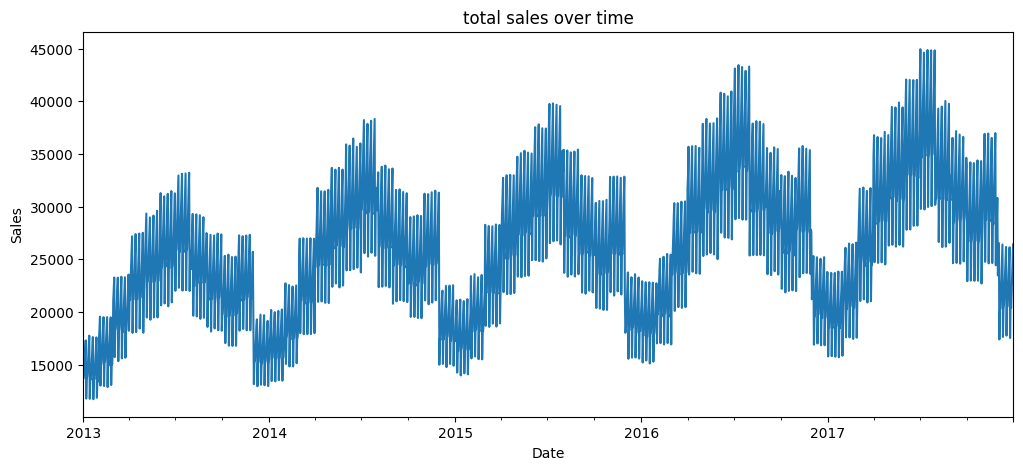

In [11]:
df.groupby('date')['sales'].sum().plot(figsize=(12,5))
plt.title("total sales over time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

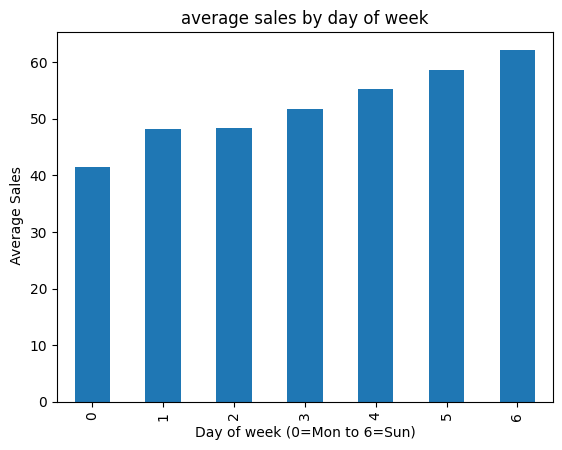

In [12]:
df.groupby('day_of_week')['sales'].mean().plot(kind='bar')
plt.title("average sales by day of week")
plt.xlabel("Day of week (0=Mon to 6=Sun)")
plt.ylabel(" Average Sales")
plt.show()

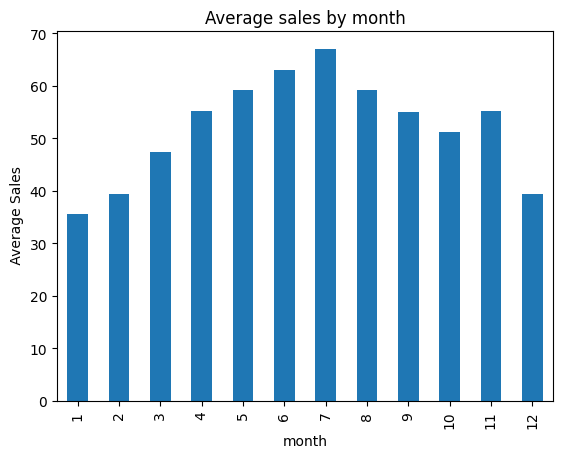

In [13]:
df.groupby('month')['sales'].mean().plot(kind='bar')
plt.title("Average sales by month")
plt.xlabel("month")
plt.ylabel(" Average Sales")
plt.show()

In [14]:
#lag features
df = df.sort_values(by=['store', 'item' , 'date'])

In [15]:
df['Lag_1'] = df.groupby(['store' , 'item'])['sales'].shift(1)
df['Lag_7'] = df.groupby(['store' , 'item'])['sales'].shift(7)
df['Lag_30'] = df.groupby(['store' , 'item'])['sales'].shift(30)

In [16]:
df.head(5)

,date,store,item,sales,year,month,day,day_of_week,Lag_1,Lag_7,Lag_30
0,2013-01-01,1,1,13,2013,1,1,1,NaN,NaN,NaN
1,2013-01-02,1,1,11,2013,1,2,2,13.0,NaN,NaN
2,2013-01-03,1,1,14,2013,1,3,3,11.0,NaN,NaN
3,2013-01-04,1,1,13,2013,1,4,4,14.0,NaN,NaN
4,2013-01-05,1,1,10,2013,1,5,5,13.0,NaN,NaN


In [17]:
df = df.dropna()

In [18]:
df.head(5)

,date,store,item,sales,year,month,day,day_of_week,Lag_1,Lag_7,Lag_30
30,2013-01-31,1,1,13,2013,1,31,3,9.0,8.0,13.0
31,2013-02-01,1,1,11,2013,2,1,4,13.0,14.0,11.0
32,2013-02-02,1,1,21,2013,2,2,5,11.0,12.0,14.0
33,2013-02-03,1,1,15,2013,2,3,6,21.0,12.0,13.0
34,2013-02-04,1,1,14,2013,2,4,0,15.0,11.0,10.0


In [19]:
df["rolling_mean_7"] = df.groupby(["store", "item"])['sales'].transform(lambda x: x.shift(1).rolling(7).mean())

In [20]:
df.head(5)

,date,store,item,sales,year,month,day,day_of_week,Lag_1,Lag_7,Lag_30,rolling_mean_7
30,2013-01-31,1,1,13,2013,1,31,3,9.0,8.0,13.0,NaN
31,2013-02-01,1,1,11,2013,2,1,4,13.0,14.0,11.0,NaN
32,2013-02-02,1,1,21,2013,2,2,5,11.0,12.0,14.0,NaN
33,2013-02-03,1,1,15,2013,2,3,6,21.0,12.0,13.0,NaN
34,2013-02-04,1,1,14,2013,2,4,0,15.0,11.0,10.0,NaN


In [21]:
df = df.dropna()

In [22]:
# putting features in x and our target in y
x = df[['store' , 'item' , 'year' , 'month' , 'day' , 'day_of_week' , 'Lag_1' , 'Lag_7'  , 'Lag_30' , 'rolling_mean_7']]
y = df['sales']

In [23]:
train = df[df['date'] < '2017-01-01']
test = df[df['date'] >= '2017-01-01']

x_train = train[x.columns]
y_train = train['sales']
x_test = test[x.columns]
y_test = test['sales']

In [24]:
#First model LinearRegression
from sklearn.linear_model import LinearRegression
model_lr = LinearRegression()
model_lr.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [25]:
y_pred_lr = model_lr.predict(x_test)

In [26]:
#model evaluation
from sklearn.metrics import mean_absolute_error
mae_lr = mean_absolute_error(y_test , y_pred_lr)
print('MAE of linear regression' , mae_lr)

MAE of linear regression 7.108169187757622


In [27]:
df['sales'].describe()

count    894500.000000
mean         52.712342
std          28.830339
min           0.000000
25%          30.000000
50%          47.000000
75%          70.000000
max         231.000000
Name: sales, dtype: float64

In [28]:
#now random forest
from sklearn.ensemble import RandomForestRegressor
model_rf = RandomForestRegressor(n_estimators=20,random_state=42)
model_rf.fit(x_train,y_train)
y_pred_rf = model_rf.predict(x_test)

In [29]:
#now we will evaluate our random forest model
from sklearn.metrics import mean_absolute_error
mae_rf = mean_absolute_error(y_test , y_pred_rf)
print('MAE of random forest' , mae_rf)

MAE of random forest 6.712575890410959


In [30]:
#now we will improve model thorugh some features improvement
df['Lag_14'] = df.groupby(['store' , 'item'])['sales'].shift(14)
df['rolling_mean_14'] = df.groupby(['store' , 'item'])['sales'].transform(lambda x: x.shift(1).rolling(14).mean())
df['rolling_mean_30'] = df.groupby(['store' , 'item'])['sales'].transform(lambda x: x.shift(1).rolling(30).mean())

In [31]:
df.dropna()

,date,store,item,sales,year,month,day,day_of_week,Lag_1,Lag_7,Lag_30,rolling_mean_7,Lag_14,rolling_mean_14,rolling_mean_30
67,2013-03-09,1,1,16,2013,3,9,5,15.0,13.0,13.0,14.714286,15.0,12.785714,12.000000
68,2013-03-10,1,1,11,2013,3,10,6,16.0,20.0,11.0,15.142857,11.0,12.857143,12.100000
69,2013-03-11,1,1,18,2013,3,11,0,11.0,14.0,14.0,13.857143,7.0,12.857143,12.100000
70,2013-03-12,1,1,14,2013,3,12,1,18.0,13.0,11.0,14.428571,9.0,13.642857,12.233333
71,2013-03-13,1,1,13,2013,3,13,2,14.0,17.0,16.0,14.571429,9.0,14.000000,12.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
912995,2017-12-27,10,50,63,2017,12,27,2,41.0,51.0,75.0,61.000000,67.0,63.071429,64.633333
912996,2017-12-28,10,50,59,2017,12,28,3,63.0,63.0,68.0,62.714286,72.0,62.785714,64.233333
912997,2017-12-29,10,50,74,2017,12,29,4,59.0,75.0,76.0,62.142857,72.0,61.857143,63.933333
912998,2017-12-30,10,50,62,2017,12,30,5,74.0,70.0,73.0,62.000000,52.0,62.000000,63.866667


In [32]:
x = df[['store', 'item', 'year', 'month', 'day', 'day_of_week',
       'Lag_1', 'Lag_7', 'Lag_30', 'rolling_mean_7']]

In [33]:
df.columns

Index(['date', 'store', 'item', 'sales', 'year', 'month', 'day', 'day_of_week',
       'Lag_1', 'Lag_7', 'Lag_30', 'rolling_mean_7', 'Lag_14',
       'rolling_mean_14', 'rolling_mean_30'],
      dtype='object')

In [34]:
df.dropna()
train = df[df['date'] < '2017-01-01']
test = df[df['date'] >= '2017-01-01']

x_train = train[x.columns]
x_test = test[x.columns]

In [37]:
from sklearn.ensemble import RandomForestRegressor
model_rf = RandomForestRegressor(n_estimators=60,random_state=42)
model_rf.fit(x_train , y_train)
y_pred_rf = model_rf.predict(x_test)

In [38]:
from sklearn.metrics import mean_absolute_error
mae_rf = mean_absolute_error(y_test , y_pred_rf)
print(mae_rf)

6.590072237442922


In [39]:
#Features Importance
feature_importance = pd.DataFrame({'feature' : x.columns, 'importance' : model_rf.feature_importances_})
feature_importance = feature_importance.sort_values(by='importance',ascending=False)
print(feature_importance)

          feature  importance
9  rolling_mean_7    0.688829
7           Lag_7    0.206789
6           Lag_1    0.028699
5     day_of_week    0.022177
8          Lag_30    0.012224
4             day    0.011852
1            item    0.010103
3           month    0.008881
0           store    0.006637
2            year    0.003810


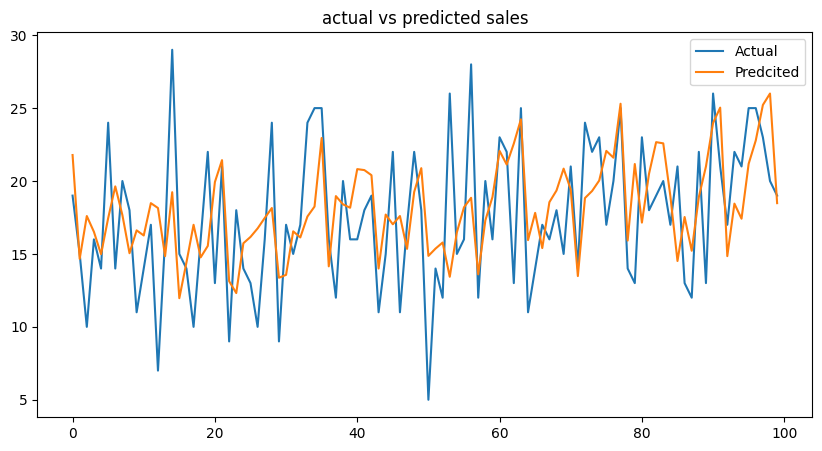

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test.values[:100] , label='Actual')
plt.plot(y_pred_rf[:100] ,label = 'Predcited')
plt.legend()
plt.title("actual vs predicted sales")
plt.show()

In [43]:
"""
PROJECT CONCLUSION--->  1. Built a demand forecasting model using time-series data.
2. Created lag features (lag_1, lag_7, lag_30) and rolling mean features.
3. Random Forest performed better than Linear Regression.
4. Final MAE achieved: 6.59 (~12-13% error).
5. Feature importance showed rolling_mean_7 as most important, indicating strong weekly trends.
6. Model captures overall trend well but struggles with sudden spikes.

BUISNESS INSIGHTS---> This model can help buisness plan inventory based on weekly demand patterns
rather than daily fluctuations.
"""

'\nPROJECT CONCLUSION--->  1. Built a demand forecasting model using time-series data.\n2. Created lag features (lag_1, lag_7, lag_30) and rolling mean features.\n3. Random Forest performed better than Linear Regression.\n4. Final MAE achieved: 6.59 (~12-13% error).\n5. Feature importance showed rolling_mean_7 as most important, indicating strong weekly trends.\n6. Model captures overall trend well but struggles with sudden spikes.\n\nBUISNESS INSIGHTS---> This model can help buisness plan inventory based on weekly demand patterns\nrather than daily fluctuations.\n'